# RADBIO_NEURO_001 — SPENVIS Physics-to-Biology Notebook

This notebook is the first executable analysis layer for the SPENVIS dataset.

It performs:

1. **LEO vs Van Allen comparison** from SHIELDOSE-2 tissue absorbed dose outputs.
2. **Dose vs shielding plots** using aluminium-equivalent shielding depth.
3. **Dose-rate conversion** from mission dose to Gy/day and mGy/day.
4. **Biology-ready forcing table** for downstream ROS/mitochondria/neural modeling.
5. **Prototype ROS/mitochondria input layer** driven by absorbed tissue dose-rate.

Important limitation: the SPENVIS effective-dose Monte Carlo outputs in this dataset contain `NaN` values, so this notebook uses **SHIELDOSE-2 absorbed tissue dose** as the defensible physics input. Effective dose/dose-equivalent should be rerun or replaced by OLTARIS/HZETRN before making biological-risk claims.

## 0. Imports and project paths

The notebook expects the parsed first-pass CSV files in `./data/`. Outputs are written to `./outputs/` and figures to `./figures/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path('.').resolve()
DATA = PROJECT / 'data'
OUT = PROJECT / 'outputs'
FIG = PROJECT / 'figures'
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

MISSION_DAYS = 180.0
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)
print('Project:', PROJECT)
print('Data files:', sorted(p.name for p in DATA.glob('*.csv')))

Project: /mnt/data/RADBIO_NEURO_001_NOTEBOOK_BUILD
Data files: ['effective_dose_output_audit.csv', 'file_audit.csv', 'leo_vs_vab_shieldose2_comparison.csv', 'selected_shielding_depth_summary.csv', 'shieldose2_tissue_dose_by_shielding.csv']


## 1. Load parsed SPENVIS outputs

Core file: `shieldose2_tissue_dose_by_shielding.csv`.

This contains absorbed dose in tissue from SHIELDOSE-2 for both scenarios:

- `LEO_ISS_like`: circular 400 km, 51.6° inclination, 180-day mission.
- `VanAllen_RBSP_like`: perigee 600 km, apogee 30600 km, 10° inclination, 180-day mission.

In [2]:
dose = pd.read_csv(DATA / 'shieldose2_tissue_dose_by_shielding.csv')
comparison = pd.read_csv(DATA / 'leo_vs_vab_shieldose2_comparison.csv')
selected = pd.read_csv(DATA / 'selected_shielding_depth_summary.csv')
eff_audit = pd.read_csv(DATA / 'effective_dose_output_audit.csv')

print('Dose table shape:', dose.shape)
display(dose.head())
print('\nEffective-dose audit:')
display(eff_audit)

Dose table shape: (50, 10)


,scenario,shield_mm_Al,total_dose_rad,total_dose_Gy,electron_dose_rad,electron_dose_Gy,brems_dose_rad,brems_dose_Gy,trapped_proton_dose_rad,trapped_proton_dose_Gy
0,LEO_ISS_like,0.05,89382.0,893.820,87405.0,874.050,208.620,2.08620,1768.40,17.6840
1,LEO_ISS_like,0.10,45547.0,455.470,44618.0,446.180,87.467,0.87467,840.83,8.4083
2,LEO_ISS_like,0.20,18048.0,180.480,17633.0,176.330,37.141,0.37141,377.75,3.7775
3,LEO_ISS_like,0.30,9128.8,91.288,8872.2,88.722,21.277,0.21277,235.34,2.3534
4,LEO_ISS_like,0.40,5457.4,54.574,5266.9,52.669,14.166,0.14166,176.35,1.7635



Effective-dose audit:


,run,layers,total_thickness_g_cm2,effective_dose_Sv,error_Sv,usable_numeric_effective_dose,source_file
0,LEO_trapped_10k,1,5.32,NaN,NaN,False,05_leo_effective_dose_trapped/15_effective_dos...
1,LEO_trapped_100k,1,5.32,NaN,NaN,False,05_leo_effective_dose_trapped/19_effective_dos...
2,VAB_trapped_10k,1,5.32,NaN,NaN,False,10_vab_effective_dose_trapped/36_vab_effective...


## 2. Effective-dose Monte Carlo audit

The effective-dose outputs are intentionally audited before use. If the effective-dose rows are `NaN`, they should not be used for biology yet. This keeps the pipeline scientifically clean: **use absorbed tissue dose now; fix dose-equivalent later**.

In [3]:
usable_eff = eff_audit['usable_numeric_effective_dose'].fillna(False).astype(bool).any()
print('Any usable numeric effective-dose result?', usable_eff)
if not usable_eff:
    print('Decision: use SHIELDOSE-2 absorbed tissue dose for this notebook; keep effective dose as a rerun target.')

Any usable numeric effective-dose result? False
Decision: use SHIELDOSE-2 absorbed tissue dose for this notebook; keep effective dose as a rerun target.


## 3. LEO vs Van Allen comparison at selected shielding depths

This table is the first compact result for a paper/product dashboard. It shows how strongly the Van Allen/RBSP-like orbit amplifies tissue dose relative to the ISS-like LEO baseline.

In [4]:
selected_view = selected.copy()
for col in ['total_dose_Gy_leo', 'total_dose_Gy_vab', 'vab_to_leo_total_dose_ratio']:
    selected_view[col] = selected_view[col].astype(float)

selected_view['leo_dose_rate_mGy_day'] = selected_view['total_dose_Gy_leo'] * 1000.0 / MISSION_DAYS
selected_view['vab_dose_rate_mGy_day'] = selected_view['total_dose_Gy_vab'] * 1000.0 / MISSION_DAYS
selected_view = selected_view[[
    'shield_mm_Al',
    'total_dose_Gy_leo', 'leo_dose_rate_mGy_day',
    'total_dose_Gy_vab', 'vab_dose_rate_mGy_day',
    'vab_to_leo_total_dose_ratio'
]]
selected_view.to_csv(OUT / 'selected_shielding_dose_rate_summary.csv', index=False)
display(selected_view)

,shield_mm_Al,total_dose_Gy_leo,leo_dose_rate_mGy_day,total_dose_Gy_vab,vab_dose_rate_mGy_day,vab_to_leo_total_dose_ratio
0,1.0,12.07200,67.066667,25203.000,140016.666667,2087.723658
1,2.0,4.44830,24.712778,6965.100,38695.000000,1565.789178
2,5.0,0.67828,3.768222,409.610,2275.611111,603.895147
3,10.0,0.27938,1.552111,33.784,187.688889,120.924905
4,20.0,0.20255,1.125278,18.393,102.183333,90.807208


## 4. Dose vs shielding plot

The y-axis is logarithmic because the Van Allen crossing case is orders of magnitude higher than the LEO baseline at low shielding depths.

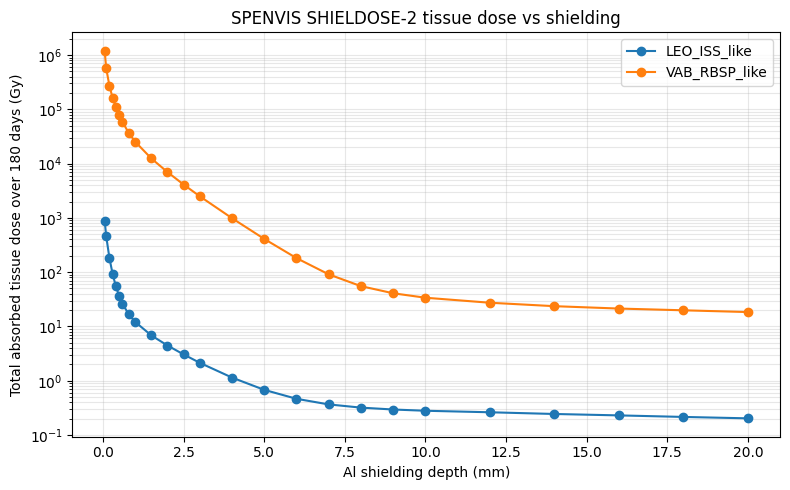

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for scenario, g in dose.groupby('scenario'):
    g = g.sort_values('shield_mm_Al')
    ax.plot(g['shield_mm_Al'], g['total_dose_Gy'], marker='o', label=scenario)
ax.set_yscale('log')
ax.set_xlabel('Al shielding depth (mm)')
ax.set_ylabel('Total absorbed tissue dose over 180 days (Gy)')
ax.set_title('SPENVIS SHIELDOSE-2 tissue dose vs shielding')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'dose_vs_shielding_total_Gy_log.png', dpi=220)
plt.show()

## 5. Convert mission dose into biology-ready dose-rate

SHIELDOSE-2 gives total mission dose for the 180-day scenario. For a biological model, the forcing variable should be a dose-rate-like input:

\[
\dot{D}_{Gy/day} = \frac{D_{mission,Gy}}{180}
\]

and

\[
\dot{D}_{mGy/day} = 1000\dot{D}_{Gy/day}
\]

In [6]:
forcing = dose.copy().sort_values(['scenario', 'shield_mm_Al']).reset_index(drop=True)
forcing['mission_days'] = MISSION_DAYS
forcing['total_dose_rate_Gy_day'] = forcing['total_dose_Gy'] / forcing['mission_days']
forcing['total_dose_rate_mGy_day'] = forcing['total_dose_rate_Gy_day'] * 1000.0
forcing['electron_dose_rate_mGy_day'] = forcing['electron_dose_Gy'] * 1000.0 / forcing['mission_days']
forcing['brems_dose_rate_mGy_day'] = forcing['brems_dose_Gy'] * 1000.0 / forcing['mission_days']
forcing['trapped_proton_dose_rate_mGy_day'] = forcing['trapped_proton_dose_Gy'] * 1000.0 / forcing['mission_days']

# Two forcing indices: one physical, one normalized for plotting/model input.
# Physical: mGy/day. Normalized: log-scaled 0 to 1 for stable prototype ROS integration.
max_rate = forcing['total_dose_rate_mGy_day'].max()
forcing['ros_forcing_index_log01'] = np.log1p(forcing['total_dose_rate_mGy_day']) / np.log1p(max_rate)

# Coarse regime label, not a safety claim.
def regime(rate_mGy_day):
    if rate_mGy_day < 0.1:
        return 'very_low_model_forcing'
    if rate_mGy_day < 1.0:
        return 'low_model_forcing'
    if rate_mGy_day < 10.0:
        return 'moderate_model_forcing'
    if rate_mGy_day < 100.0:
        return 'high_model_forcing'
    return 'extreme_model_forcing'

forcing['forcing_regime_label'] = forcing['total_dose_rate_mGy_day'].apply(regime)
forcing['recommended_use'] = np.where(
    forcing['scenario'].str.contains('VanAllen'),
    'stress-test / belt-crossing comparison, not a normal astronaut-habitat case',
    'baseline LEO comparison case'
)

biology_forcing = forcing[[
    'scenario', 'shield_mm_Al', 'mission_days',
    'total_dose_Gy', 'total_dose_rate_Gy_day', 'total_dose_rate_mGy_day',
    'electron_dose_rate_mGy_day', 'brems_dose_rate_mGy_day', 'trapped_proton_dose_rate_mGy_day',
    'ros_forcing_index_log01', 'forcing_regime_label', 'recommended_use'
]]
biology_forcing.to_csv(OUT / 'biology_ready_dose_forcing_table.csv', index=False)
display(biology_forcing.head(12))

,scenario,shield_mm_Al,mission_days,total_dose_Gy,total_dose_rate_Gy_day,total_dose_rate_mGy_day,electron_dose_rate_mGy_day,brems_dose_rate_mGy_day,trapped_proton_dose_rate_mGy_day,ros_forcing_index_log01,forcing_regime_label,recommended_use
0,LEO_ISS_like,0.05,180.0,893.8200,4.965667,4965.666667,4855.833333,11.590000,98.244444,0.541609,extreme_model_forcing,baseline LEO comparison case
1,LEO_ISS_like,0.10,180.0,455.4700,2.530389,2530.388889,2478.777778,4.859278,46.712778,0.498717,extreme_model_forcing,baseline LEO comparison case
2,LEO_ISS_like,0.20,180.0,180.4800,1.002667,1002.666667,979.611111,2.063389,20.986111,0.439843,extreme_model_forcing,baseline LEO comparison case
3,LEO_ISS_like,0.30,180.0,91.2880,0.507156,507.155556,492.900000,1.182056,13.074444,0.396528,extreme_model_forcing,baseline LEO comparison case
4,LEO_ISS_like,0.40,180.0,54.5740,0.303189,303.188889,292.605556,0.787000,9.797222,0.363871,extreme_model_forcing,baseline LEO comparison case
5,LEO_ISS_like,0.50,180.0,36.3390,0.201883,201.883333,193.327778,0.552172,8.003889,0.338096,extreme_model_forcing,baseline LEO comparison case
6,LEO_ISS_like,0.60,180.0,26.2870,0.146039,146.038889,138.861111,0.407522,6.768889,0.317608,extreme_model_forcing,baseline LEO comparison case
7,LEO_ISS_like,0.80,180.0,16.6450,0.092472,92.472222,87.005556,0.267111,5.198111,0.288777,high_model_forcing,baseline LEO comparison case
8,LEO_ISS_like,1.00,180.0,12.0720,0.067067,67.066667,62.583333,0.200800,4.280389,0.268592,high_model_forcing,baseline LEO comparison case
9,LEO_ISS_like,1.50,180.0,6.8198,0.037888,37.887778,34.529444,0.121194,3.236944,0.232966,high_model_forcing,baseline LEO comparison case


## 6. Dose-rate vs shielding plot

This is the product-facing plot: it directly shows the input intensity that will drive the ROS/mitochondria layer.

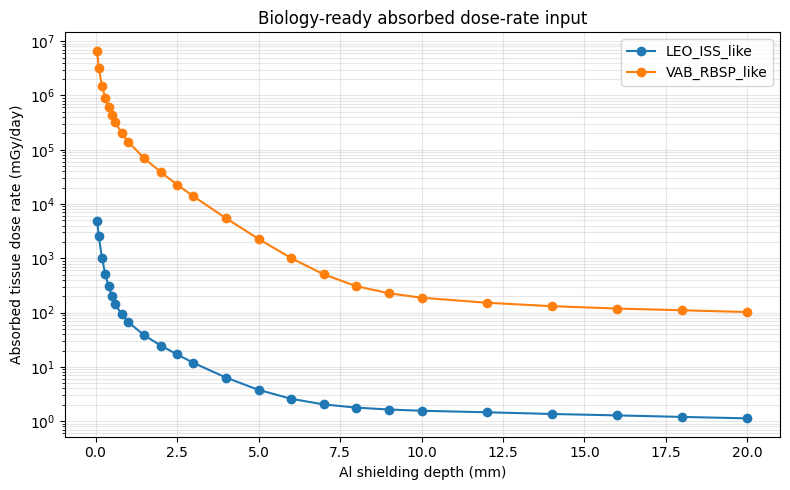

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for scenario, g in biology_forcing.groupby('scenario'):
    g = g.sort_values('shield_mm_Al')
    ax.plot(g['shield_mm_Al'], g['total_dose_rate_mGy_day'], marker='o', label=scenario)
ax.set_yscale('log')
ax.set_xlabel('Al shielding depth (mm)')
ax.set_ylabel('Absorbed tissue dose rate (mGy/day)')
ax.set_title('Biology-ready absorbed dose-rate input')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'biology_ready_dose_rate_vs_shielding_mGy_day.png', dpi=220)
plt.show()

## 7. Prototype ROS/mitochondria input layer

This is **not yet a validated biological model**. It is an input-layer scaffold that converts SPENVIS absorbed dose-rate into normalized ROS and mitochondrial-integrity state variables.

The final research/product version should replace the provisional parameters below with literature-calibrated values and should include separate fast redox-channel effects and slow bioenergetic/mitochondrial failure effects.

Prototype state variables:

- `R(t)`: normalized ROS burden, bounded 0–1.
- `M(t)`: mitochondrial integrity, bounded 0–1.
- `fast_redox_channel_stress`: acute ROS-linked excitability perturbation.
- `slow_mito_pump_stress`: chronic mitochondrial/ATP-linked impairment.
- `neural_risk_proxy`: weighted combination for visualization only.

In [8]:
BIOLOGY_PARAMS = {
    'alpha_per_mGy': 0.015,      # provisional ROS induction strength per mGy/day
    'k_scav_day': 0.25,          # provisional ROS clearance / antioxidant buffering per day
    'k_damage_day': 0.015,       # provisional mitochondrial damage coupling per day
    'k_repair_day': 0.003,       # provisional slow recovery/adaptation per day
    'fast_weight': 0.40,
    'slow_weight': 0.60,
}

print(BIOLOGY_PARAMS)

{'alpha_per_mGy': 0.015, 'k_scav_day': 0.25, 'k_damage_day': 0.015, 'k_repair_day': 0.003, 'fast_weight': 0.4, 'slow_weight': 0.6}


In [9]:
def simulate_ros_mito(dose_rate_mGy_day, days=180, params=BIOLOGY_PARAMS):
    # Daily prototype ROS/mitochondria state update.
    # Input: absorbed tissue dose rate in mGy/day from SPENVIS-derived SHIELDOSE-2 table.
    # Output: normalized state variables for downstream neural modeling.
    # This is intentionally bounded and stable for extreme stress-test cases.
    alpha = params['alpha_per_mGy']
    k_scav = params['k_scav_day']
    k_damage = params['k_damage_day']
    k_repair = params['k_repair_day']
    fast_w = params['fast_weight']
    slow_w = params['slow_weight']

    R = np.zeros(days + 1)
    M = np.ones(days + 1)
    dose = np.full(days + 1, dose_rate_mGy_day, dtype=float)

    # Bounded induction term from dose-rate.
    ros_induction = 1.0 - np.exp(-alpha * dose_rate_mGy_day)

    for t in range(days):
        dR = ros_induction * (1.0 - R[t]) - k_scav * R[t]
        R[t+1] = np.clip(R[t] + dR, 0.0, 1.0)

        dM = k_repair * (1.0 - M[t]) - k_damage * R[t] * M[t]
        M[t+1] = np.clip(M[t] + dM, 0.0, 1.0)

    fast = R.copy()
    slow = 1.0 - M.copy()
    risk = np.clip(fast_w * fast + slow_w * slow, 0.0, 1.0)

    return pd.DataFrame({
        'day': np.arange(days + 1),
        'dose_rate_mGy_day': dose,
        'ros_norm_R': R,
        'mitochondrial_integrity_M': M,
        'fast_redox_channel_stress': fast,
        'slow_mito_pump_stress': slow,
        'neural_risk_proxy_0to1': risk,
    })

## 8. Simulate ROS/mitochondria layer for selected shielding depths

We create daily time courses for practical shielding depths: 1, 2, 5, 10, and 20 mm Al.

In [10]:
selected_depths = [1, 2, 5, 10, 20]
rows = []
timecourses = []

for _, row in biology_forcing[biology_forcing['shield_mm_Al'].isin(selected_depths)].iterrows():
    tc = simulate_ros_mito(row['total_dose_rate_mGy_day'], days=int(MISSION_DAYS))
    tc.insert(0, 'scenario', row['scenario'])
    tc.insert(1, 'shield_mm_Al', row['shield_mm_Al'])
    timecourses.append(tc)
    end = tc.iloc[-1].to_dict()
    rows.append({
        'scenario': row['scenario'],
        'shield_mm_Al': row['shield_mm_Al'],
        'total_dose_Gy_180d': row['total_dose_Gy'],
        'dose_rate_mGy_day': row['total_dose_rate_mGy_day'],
        'endpoint_ros_norm_R': end['ros_norm_R'],
        'endpoint_mitochondrial_integrity_M': end['mitochondrial_integrity_M'],
        'endpoint_fast_redox_channel_stress': end['fast_redox_channel_stress'],
        'endpoint_slow_mito_pump_stress': end['slow_mito_pump_stress'],
        'endpoint_neural_risk_proxy_0to1': end['neural_risk_proxy_0to1'],
    })

bio_timecourse = pd.concat(timecourses, ignore_index=True)
bio_endpoints = pd.DataFrame(rows).sort_values(['scenario', 'shield_mm_Al'])

bio_timecourse.to_csv(OUT / 'prototype_ros_mito_daily_timecourses.csv', index=False)
bio_endpoints.to_csv(OUT / 'prototype_ros_mito_endpoints_selected_shielding.csv', index=False)

display(bio_endpoints)

,scenario,shield_mm_Al,total_dose_Gy_180d,dose_rate_mGy_day,endpoint_ros_norm_R,endpoint_mitochondrial_integrity_M,endpoint_fast_redox_channel_stress,endpoint_slow_mito_pump_stress,endpoint_neural_risk_proxy_0to1
0,LEO_ISS_like,1.0,12.07200,67.066667,0.717297,0.283633,0.717297,0.716367,0.716739
1,LEO_ISS_like,2.0,4.44830,24.712778,0.553367,0.362397,0.553367,0.637603,0.603908
2,LEO_ISS_like,5.0,0.67828,3.768222,0.180208,0.698541,0.180208,0.301459,0.252959
3,LEO_ISS_like,10.0,0.27938,1.552111,0.084292,0.843067,0.084292,0.156933,0.127876
4,LEO_ISS_like,20.0,0.20255,1.125278,0.062749,0.880257,0.062749,0.119743,0.096946
5,VAB_RBSP_like,1.0,25203.00000,140016.666667,0.800000,0.253315,0.800000,0.746685,0.768011
6,VAB_RBSP_like,2.0,6965.10000,38695.000000,0.800000,0.253315,0.800000,0.746685,0.768011
7,VAB_RBSP_like,5.0,409.61000,2275.611111,0.800000,0.253315,0.800000,0.746685,0.768011
8,VAB_RBSP_like,10.0,33.78400,187.688889,0.789936,0.256727,0.789936,0.743273,0.761938
9,VAB_RBSP_like,20.0,18.39300,102.183333,0.758234,0.267960,0.758234,0.732040,0.742518


## 9. ROS and mitochondrial integrity at 10 mm Al

The 10 mm Al case is a useful first comparison point because it avoids the most extreme thin-shielding values while still showing the difference between LEO and belt-crossing exposure.

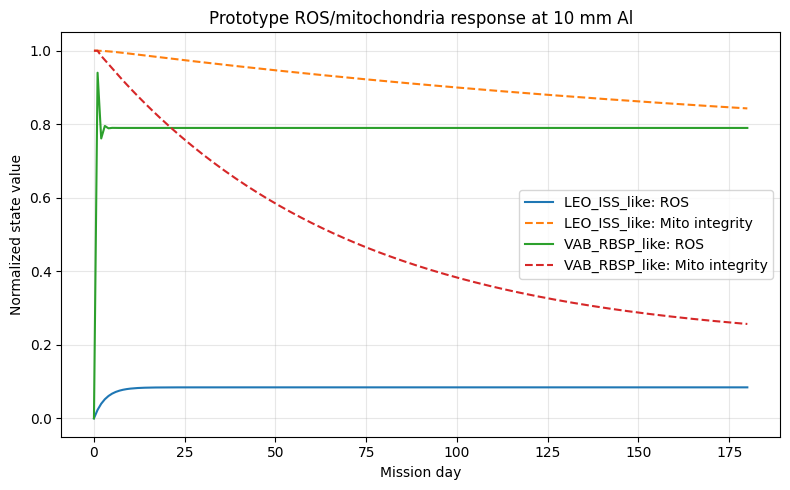

In [11]:
plot_tc = bio_timecourse[bio_timecourse['shield_mm_Al'].eq(10.0)]

fig, ax = plt.subplots(figsize=(8, 5))
for label, g in plot_tc.groupby('scenario'):
    ax.plot(g['day'], g['ros_norm_R'], label=f'{label}: ROS')
    ax.plot(g['day'], g['mitochondrial_integrity_M'], linestyle='--', label=f'{label}: Mito integrity')
ax.set_xlabel('Mission day')
ax.set_ylabel('Normalized state value')
ax.set_title('Prototype ROS/mitochondria response at 10 mm Al')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'prototype_ros_mito_timecourse_10mm.png', dpi=220)
plt.show()

## 10. Endpoint neural-risk proxy summary

This proxy is not a validated cognitive-risk predictor. It is a placeholder output for product/dashboard development until the biology parameters are calibrated against experimental dose-response data.

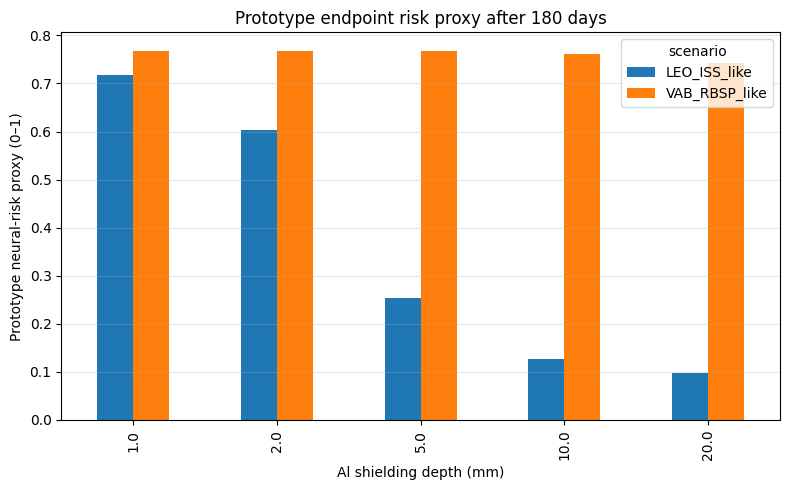

scenario,LEO_ISS_like,VAB_RBSP_like
shield_mm_Al,,
1.0,0.716739,0.768011
2.0,0.603908,0.768011
5.0,0.252959,0.768011
10.0,0.127876,0.761938
20.0,0.096946,0.742518


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
endpoint_pivot = bio_endpoints.pivot(index='shield_mm_Al', columns='scenario', values='endpoint_neural_risk_proxy_0to1')
endpoint_pivot.plot(kind='bar', ax=ax)
ax.set_xlabel('Al shielding depth (mm)')
ax.set_ylabel('Prototype neural-risk proxy (0–1)')
ax.set_title('Prototype endpoint risk proxy after 180 days')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / 'prototype_endpoint_neural_risk_proxy.png', dpi=220)
plt.show()

endpoint_pivot

## 11. Product-ready output map

The output files generated by this notebook are:

- `outputs/biology_ready_dose_forcing_table.csv`
- `outputs/selected_shielding_dose_rate_summary.csv`
- `outputs/prototype_ros_mito_daily_timecourses.csv`
- `outputs/prototype_ros_mito_endpoints_selected_shielding.csv`
- `figures/dose_vs_shielding_total_Gy_log.png`
- `figures/biology_ready_dose_rate_vs_shielding_mGy_day.png`
- `figures/prototype_ros_mito_timecourse_10mm.png`
- `figures/prototype_endpoint_neural_risk_proxy.png`

Recommended next scientific upgrade:

1. Rerun/fix dose-equivalent outputs or use OLTARIS for GCR LET/dose equivalent.
2. Add calibration table from real radiation-neurobiology studies.
3. Replace prototype ROS/mitochondria parameters with literature/provenance-tagged values.
4. Split neural effects into fast redox channel modulation and slow mitochondrial/ATP/pump failure.

In [13]:
print('Wrote outputs:')
for p in sorted(OUT.glob('*')):
    print(' -', p.relative_to(PROJECT))
print('\nWrote figures:')
for p in sorted(FIG.glob('*.png')):
    print(' -', p.relative_to(PROJECT))

Wrote outputs:
 - outputs/biology_ready_dose_forcing_table.csv
 - outputs/prototype_ros_mito_daily_timecourses.csv
 - outputs/prototype_ros_mito_endpoints_selected_shielding.csv
 - outputs/selected_shielding_dose_rate_summary.csv

Wrote figures:
 - figures/biology_ready_dose_rate_vs_shielding_mGy_day.png
 - figures/dose_vs_shielding_total_Gy_log.png
 - figures/firstpass_dose_vs_shielding_proton_Gy.png
 - figures/firstpass_dose_vs_shielding_total_Gy.png
 - figures/firstpass_vab_to_leo_total_dose_ratio.png
 - figures/prototype_endpoint_neural_risk_proxy.png
 - figures/prototype_ros_mito_timecourse_10mm.png
